# Emotion Classification with Fine-Tuned BERT



---
## 1. Setup



In [1]:
%pip install -q transformers datasets torch scikit-learn matplotlib seaborn pandas

In [2]:
import os
import copy
import random
import time
from dataclasses import dataclass, replace

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

from torch.utils.data import DataLoader
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    get_linear_schedule_with_warmup,
)
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

# Silence the tokenizer's fork warning, which is noisy inside notebooks.
os.environ["TOKENIZERS_PARALLELISM"] = "false"

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_colwidth", 90)

In [3]:
@dataclass
class Config:
    """Single source of truth for every experimental setting."""

    # --- data ---
    dataset_name: str = "dair-ai/emotion"
    dataset_config: str = "split"          # ships with train/validation/test already
    max_length: int = 64                   # PROVISIONAL — re-derived empirically in Section 3

    # --- model ---
    model_name: str = "bert-base-uncased"

    # --- optimisation ---
    learning_rate: float = 2e-5
    batch_size: int = 32
    epochs: int = 5                        # curves showed metrics still rising at 3
    patience: int = 2                      # stop if val macro-F1 stalls this many epochs
    weight_decay: float = 0.01             # not applied to bias / LayerNorm (see Section 8)
    warmup_ratio: float = 0.1              # 10% linear warmup is the standard BERT recipe
    max_grad_norm: float = 1.0             # clipping guards against rare exploding batches

    # --- experiment control ---
    seed: int = 42
    tune_subsample: float = 0.5            # fraction of train used during the search (Section 9)
    tune_epochs: int = 2                   # shorter runs during the search, full runs after
    use_class_weights: bool = False        # toggled by the ablation in Section 10
    n_final_seeds: int = 1                 # raise to 3 to report mean +/- std (3x runtime)


CFG = Config()


def set_seed(seed: int) -> None:
    """Seed every RNG that affects training, so runs are reproducible."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def get_device() -> torch.device:
    """Pick the best available accelerator; falls back to CPU so the notebook always runs."""
    if torch.cuda.is_available():
        return torch.device("cuda")
    if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
        return torch.device("mps")   # Apple Silicon
    return torch.device("cpu")


set_seed(CFG.seed)
DEVICE = get_device()
print(f"Device: {DEVICE}")
print(f"Model:  {CFG.model_name}")

Device: cuda
Model:  bert-base-uncased


---
## 2. Data loading

`dair-ai/emotion` was built by Saravia et al. (2018) using *distant supervision*: tweets
containing emotion hashtags were collected and the hashtag became the label. This gives a
large dataset cheaply, but it also means the labels are noisy — a caveat returned to in
Section 13.

The `split` config provides an official train/validation/test partition (16k/2k/2k).
Using the authors' own splits, rather than re-partitioning, is what makes results
comparable to published numbers.

In [4]:
def load_emotion_dataset(cfg: Config):
    """Load the dataset and return it alongside its human-readable label names."""
    ds = load_dataset(cfg.dataset_name, cfg.dataset_config)
    label_names = ds["train"].features["label"].names
    return ds, label_names


def to_dataframe(split) -> pd.DataFrame:
    """Convert a HF split to pandas — more convenient for the EDA in Section 3."""
    return pd.DataFrame({"text": split["text"], "label": split["label"]})


raw_datasets, LABEL_NAMES = load_emotion_dataset(CFG)
NUM_LABELS = len(LABEL_NAMES)

train_df = to_dataframe(raw_datasets["train"])
val_df = to_dataframe(raw_datasets["validation"])
test_df = to_dataframe(raw_datasets["test"])

print(raw_datasets)
print(f"\nLabels ({NUM_LABELS}): {LABEL_NAMES}")
print(f"\nSplit sizes -> train {len(train_df):,} | val {len(val_df):,} | test {len(test_df):,}")
train_df.head()

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

Labels (6): ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

Split sizes -> train 16,000 | val 2,000 | test 2,000


,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned hopeful just from being around someone ...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplace i will know that it is still on the pr...,2
4,i am feeling grouchy,3


---
## 3. Exploratory data analysis



### 3.1 Class distribution

The first thing to establish is whether the classes are balanced, because that determines
which metric can be trusted.

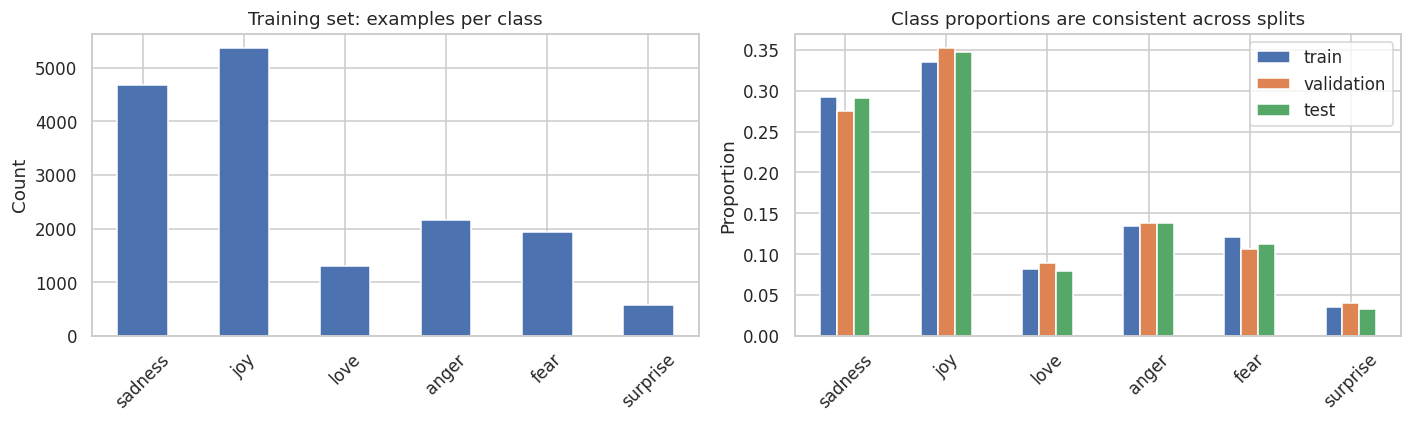

          train_count  train_pct
sadness          4666       29.2
joy              5362       33.5
love             1304        8.2
anger            2159       13.5
fear             1937       12.1
surprise          572        3.6

Imbalance ratio (largest / smallest class): 9.4x


In [5]:
def plot_class_distribution(splits: dict, label_names: list) -> pd.DataFrame:
    """Plot per-split class proportions and return the underlying counts."""
    counts = pd.DataFrame(
        {name: df["label"].value_counts().sort_index() for name, df in splits.items()}
    )
    counts.index = label_names

    proportions = counts / counts.sum()

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    counts["train"].plot(kind="bar", ax=axes[0], color=sns.color_palette("deep")[0])
    axes[0].set_title("Training set: examples per class")
    axes[0].set_ylabel("Count")
    axes[0].tick_params(axis="x", rotation=45)

    # Comparing proportions across splits confirms the splits are drawn from one
    # distribution; if they were not, validation would be a poor guide to test.
    proportions.plot(kind="bar", ax=axes[1])
    axes[1].set_title("Class proportions are consistent across splits")
    axes[1].set_ylabel("Proportion")
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

    return counts


class_counts = plot_class_distribution(
    {"train": train_df, "validation": val_df, "test": test_df}, LABEL_NAMES
)

summary = pd.DataFrame({
    "train_count": class_counts["train"],
    "train_pct": (100 * class_counts["train"] / class_counts["train"].sum()).round(1),
})
print(summary)

imbalance_ratio = class_counts["train"].max() / class_counts["train"].min()
print(f"\nImbalance ratio (largest / smallest class): {imbalance_ratio:.1f}x")

> **Decision.** The classes are substantially imbalanced. A model that ignored the rarest
> class entirely would still score well on plain accuracy, so **macro-F1 is used as the
> primary metric** throughout — for early stopping, for model selection in the
> hyperparameter search, and as the headline result. Accuracy is reported alongside it for
> comparability with published work, not as the basis for any decision.
>
> The rarest class also has by far the fewest training examples, which gives us an
> advance prediction: it should be the weakest class at test time. Section 11 checks that.

### 3.2 Text length → choosing `max_length`

`max_length` controls a direct trade-off: too short and text is truncated (information
lost), too long and compute is wasted, since self-attention cost grows quadratically with
sequence length. Rather than guessing, the value is set from the empirical token-length
distribution — measured with the *actual* tokenizer, since WordPiece splits rare words
into multiple sub-tokens and so token counts exceed word counts.

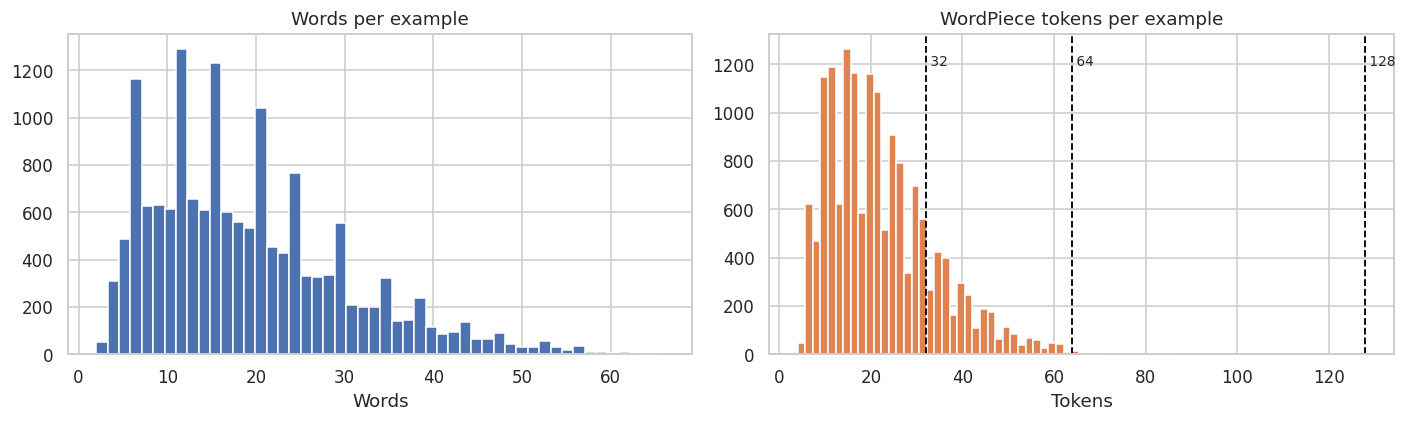

Token-length statistics:
mean      22.3
median    20.0
p95       45.0
p99       57.0
max       87.0
dtype: float64

Truncation cost by candidate max_length:
  max_length=  32: 17.79% of examples truncated
  max_length=  64:  0.16% of examples truncated
  max_length= 128:  0.00% of examples truncated


In [6]:
def analyse_text_lengths(df: pd.DataFrame, tokenizer, candidate_lengths=(32, 64, 128)):
    """Compare word- and token-length distributions, and report truncation cost."""
    word_lengths = df["text"].str.split().str.len()

    # add_special_tokens=True so [CLS] and [SEP] are counted — they occupy real budget.
    token_lengths = np.array([
        len(tokenizer.encode(t, add_special_tokens=True)) for t in df["text"]
    ])

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].hist(word_lengths, bins=50, color=sns.color_palette("deep")[0])
    axes[0].set_title("Words per example")
    axes[0].set_xlabel("Words")

    axes[1].hist(token_lengths, bins=50, color=sns.color_palette("deep")[1])
    axes[1].set_title("WordPiece tokens per example")
    axes[1].set_xlabel("Tokens")
    for L in candidate_lengths:
        axes[1].axvline(L, ls="--", lw=1.2, color="black")
        axes[1].text(L, axes[1].get_ylim()[1] * 0.9, f" {L}", fontsize=9)

    plt.tight_layout()
    plt.show()

    stats = pd.Series({
        "mean": token_lengths.mean(),
        "median": np.median(token_lengths),
        "p95": np.percentile(token_lengths, 95),
        "p99": np.percentile(token_lengths, 99),
        "max": token_lengths.max(),
    }).round(1)
    print("Token-length statistics:\n", stats, sep="")

    print("\nTruncation cost by candidate max_length:")
    for L in candidate_lengths:
        pct = 100 * (token_lengths > L).mean()
        print(f"  max_length={L:>4}: {pct:5.2f}% of examples truncated")

    return token_lengths


tokenizer = AutoTokenizer.from_pretrained(CFG.model_name)
train_token_lengths = analyse_text_lengths(train_df, tokenizer)

In [7]:
# Set max_length from the data: the smallest power of two that keeps truncation
# below 1%, so almost nothing is lost while compute stays low.
def choose_max_length(token_lengths, candidates=(32, 64, 128, 256), tolerance=0.01) -> int:
    """Smallest candidate length that truncates less than `tolerance` of examples."""
    for L in candidates:
        if (token_lengths > L).mean() < tolerance:
            return L
    return candidates[-1]


CFG = replace(CFG, max_length=choose_max_length(train_token_lengths))
print(f"max_length set empirically to {CFG.max_length}")

max_length set empirically to 64


### 3.3 Is length itself a clue?

If one emotion were systematically much longer than the others, a model could partly
"cheat" by learning length rather than meaning. Worth checking before trusting the results.

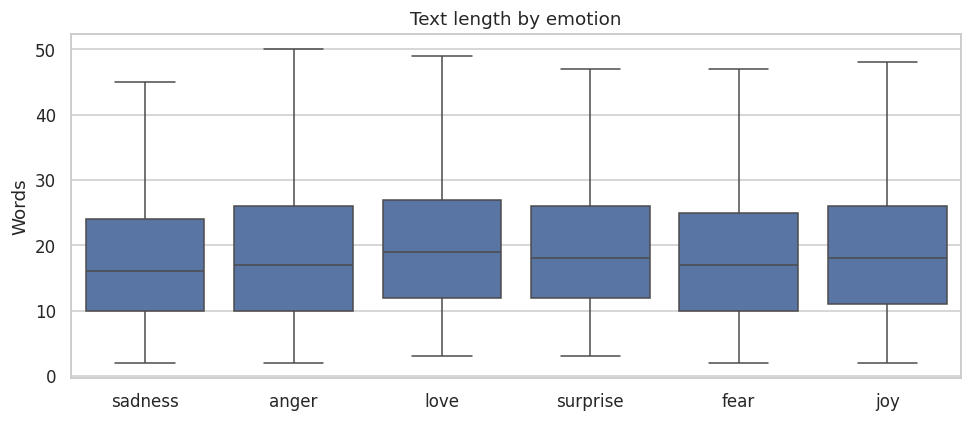

          mean   50%   std
emotion                   
anger     19.2  17.0  11.4
fear      18.8  17.0  10.9
joy       19.5  18.0  10.8
love      20.7  19.0  10.8
sadness   18.4  16.0  11.0
surprise  20.0  18.0  11.0


In [8]:
def plot_length_by_class(df: pd.DataFrame, label_names: list) -> None:
    """Boxplot of word count per class, to expose length as a potential shortcut feature."""
    plot_df = df.assign(
        emotion=df["label"].map(dict(enumerate(label_names))),
        n_words=df["text"].str.split().str.len(),
    )
    plt.figure(figsize=(9, 4))
    sns.boxplot(data=plot_df, x="emotion", y="n_words", showfliers=False)
    plt.title("Text length by emotion")
    plt.xlabel("")
    plt.ylabel("Words")
    plt.tight_layout()
    plt.show()

    print(plot_df.groupby("emotion")["n_words"].describe()[["mean", "50%", "std"]].round(1))


plot_length_by_class(train_df, LABEL_NAMES)

### 3.4 Distinctive vocabulary per class

Because the labels came from hashtags, the emotion words themselves often remain in the
text. Ranking words by how much more likely they are within a class than outside it
(a log-odds ratio, smoothed to avoid rewarding rare words) makes any such leakage visible.

In [9]:
def distinctive_words(df: pd.DataFrame, label_names: list, top_n=10, min_count=20) -> pd.DataFrame:
    """Rank words per class by smoothed log-odds against the rest of the corpus.

    Raw frequency would just return stopwords for every class; the log-odds ratio
    instead surfaces words that are *disproportionately* associated with one class.
    """
    vectoriser = CountVectorizer(min_df=min_count, stop_words="english")
    X = vectoriser.fit_transform(df["text"])
    vocab = np.array(vectoriser.get_feature_names_out())
    labels = df["label"].values

    results = {}
    for idx, name in enumerate(label_names):
        in_class = np.asarray(X[labels == idx].sum(axis=0)).ravel()
        out_class = np.asarray(X[labels != idx].sum(axis=0)).ravel()

        # +1 smoothing keeps the ratio finite for words absent from one side.
        p_in = (in_class + 1) / (in_class.sum() + len(vocab))
        p_out = (out_class + 1) / (out_class.sum() + len(vocab))
        log_odds = np.log(p_in / p_out)

        results[name] = vocab[np.argsort(-log_odds)[:top_n]]

    return pd.DataFrame(results)


print("Most distinctive words per emotion:\n")
print(distinctive_words(train_df, LABEL_NAMES))

Most distinctive words per emotion:

         sadness          joy           love         anger          fear  \
0         gloomy     superior    sympathetic       envious  apprehensive   
1   disheartened      festive          horny      offended        shaken   
2     inadequate       clever           fond  dissatisfied    distressed   
3       listless     resolved  compassionate        bitchy    suspicious   
4    unimportant    energetic          loyal     heartless     pressured   
5       deprived  intelligent         tender    rebellious    distraught   
6    unfortunate     virtuous        longing        greedy         shaky   
7         doomed     artistic      nostalgic     resentful     reluctant   
8     submissive  invigorated       delicate     dangerous       frantic   
9  disillusioned    contented         gentle       hostile   intimidated   

      surprise  
0    impressed  
1        dazed  
2       amazed  
3      curious  
4      stunned  
5      shocked  
6    su

> **Observation.** The top words for each class are largely the emotion terms themselves.
> This is a direct consequence of the distant-supervision collection method, and it has
> two consequences worth stating honestly: it inflates the achievable score (part of the
> task is closer to keyword spotting than emotion understanding), and it means performance
> here will not transfer to text where people express emotion without naming it.

### 3.5 Data hygiene

Duplicates within a split waste capacity; overlap *between* train and test invalidates the
test score entirely. Checking costs one cell and the result is worth reporting either way.

In [10]:
def check_data_hygiene(splits: dict) -> None:
    """Report empty strings, within-split duplicates, and cross-split leakage."""
    for name, df in splits.items():
        n_empty = (df["text"].str.strip() == "").sum()
        n_dupes = df["text"].duplicated().sum()
        print(f"{name:<11} empty: {n_empty:>4} | duplicate texts: {n_dupes:>4}")

    train_texts = set(splits["train"]["text"])
    for name in ("validation", "test"):
        overlap = len(train_texts & set(splits[name]["text"]))
        flag = "OK" if overlap == 0 else "LEAKAGE - investigate"
        print(f"train/{name} overlap: {overlap} ({flag})")


check_data_hygiene({"train": train_df, "validation": val_df, "test": test_df})

train       empty:    0 | duplicate texts:   31
validation  empty:    0 | duplicate texts:    2
test        empty:    0 | duplicate texts:    0
train/validation overlap: 5 (LEAKAGE - investigate)
train/test overlap: 11 (LEAKAGE - investigate)


---
## 4. Preprocessing

BERT requires its own tokenizer — the one paired with the pretrained checkpoint — because
the model's embedding matrix is indexed by that exact vocabulary. `AutoTokenizer` loads
the matching WordPiece tokenizer, which adds `[CLS]` and `[SEP]` and splits unknown words
into sub-word units so nothing maps to `[UNK]`.

Two deliberate choices:

- **No manual cleaning.** No lowercasing, stopword removal, or stemming. Those steps help
  bag-of-words models but actively hurt BERT, which was pretrained on natural text and uses
  context and word order. (`bert-base-uncased` lowercases internally anyway.)
- **Dynamic padding.** Padding to the longest sequence *per batch* rather than to a fixed
  `max_length` avoids computing attention over padding tokens, which is a meaningful
  speed-up on a dataset where the median length is far below the maximum.

In [11]:
def encode_dataset(dataset, tokenizer, max_length: int):
    """Tokenize a HF dataset, keeping it in plain-Python format.

    Two deliberate choices here:
    - Padding is NOT applied; the collator pads per batch instead (dynamic padding).
    - The dataset is NOT set to "torch" format. The collator returns tensors anyway,
      so tensorising twice is redundant. Column selection also drops token_type_ids,
      which BERT defaults to zeros for and which other checkpoints (e.g. RoBERTa) do
      not use, so the pipeline stays checkpoint-agnostic.
    """
    def tokenize(batch):
        return tokenizer(batch["text"], truncation=True, max_length=max_length)

    encoded = dataset.map(tokenize, batched=True, remove_columns=["text"])
    encoded = encoded.rename_column("label", "labels")   # name the collator expects
    encoded.set_format(type=None, columns=["input_ids", "attention_mask", "labels"])
    return encoded


def build_dataloader(encoded_split, tokenizer, batch_size: int, shuffle: bool) -> DataLoader:
    """Wrap an encoded split in a DataLoader with dynamic padding.

    DataCollatorWithPadding pads each batch to its own longest sequence and returns
    PyTorch tensors, so no separate tensor-conversion step is needed.
    """
    collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt")
    return DataLoader(
        encoded_split,
        batch_size=batch_size,
        shuffle=shuffle,           # shuffle training data only; eval order is irrelevant
        collate_fn=collator,
    )


encoded_datasets = encode_dataset(raw_datasets, tokenizer, CFG.max_length)
print(encoded_datasets)
# `labels` is a scalar while the other fields are lists, so slice only what is sliceable.
example = encoded_datasets["train"][0]
print("\nExample encoded record (lists, not tensors - the collator converts):")
print({k: (v[:12] if isinstance(v, list) else v) for k, v in example.items()})

# Verify the collator produces correctly shaped tensors before training depends on it.
_check = next(iter(build_dataloader(encoded_datasets["train"], tokenizer, 4, shuffle=False)))
print("\nCollated batch:", {k: tuple(v.shape) for k, v in _check.items()})

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})

Example encoded record (lists, not tensors - the collator converts):
{'labels': 0, 'input_ids': [101, 1045, 2134, 2102, 2514, 26608, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1]}

Collated batch: {'labels': (4,), 'input_ids': (4, 23), 'attention_mask': (4, 23)}


---
## 5. Evaluation metrics

One metrics function is used by **every** model in this notebook — both baselines and the
fine-tuned model. Sharing it guarantees the comparison in Section 11 is like-for-like, and
avoids the subtle bug of computing an average differently in two places.

Why each metric:

- **Accuracy** — intuitive and comparable to published results, but flattered by imbalance.
- **Macro-F1** — averages F1 across classes with *equal weight per class*, so the rare
  classes count as much as the common ones. This is the primary metric.
- **Weighted-F1** — weights by class frequency; sits between the two and tracks accuracy.
- **Per-class precision/recall/F1** — where the actual diagnosis happens (Section 11).

In [12]:
def compute_metrics(y_true, y_pred) -> dict:
    """Compute the metric suite used to evaluate and compare every model."""
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    _, _, weighted_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": macro_p,
        "macro_recall": macro_r,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
    }


def format_metrics(name: str, metrics: dict) -> str:
    """One-line human-readable summary, used for progress printing."""
    return (f"{name:<28} acc {metrics['accuracy']:.4f} | "
            f"macro-F1 {metrics['macro_f1']:.4f} | "
            f"weighted-F1 {metrics['weighted_f1']:.4f}")


results_registry = {}   # every model's test metrics land here for the Section 11 comparison

---
## 6. Baseline models

Fine-tuning is only worth its cost if it beats simpler alternatives, so two baselines are
established first. They bracket the problem:

1. **TF-IDF + Logistic Regression** — a classical bag-of-words model. No word order, no
   context, no pretrained knowledge. This is the floor.
2. **Frozen BERT + Logistic Regression** — BERT's pretrained `[CLS]` embeddings with a
   linear classifier on top, *without* updating BERT's weights. This isolates the value of
   pretrained representations from the value of fine-tuning, and directly addresses the
   "pre-trained BERT only" comparison in the brief.

The gap between baseline 2 and the fine-tuned model in Section 11 is precisely the value
added by adapting the encoder to this task.

In [13]:
def run_tfidf_baseline(train_df, test_df, seed: int) -> dict:
    """TF-IDF unigrams+bigrams into multinomial logistic regression."""
    vectoriser = TfidfVectorizer(
        ngram_range=(1, 2),      # bigrams capture short negations such as "not happy"
        min_df=2,                # drop hapax terms that cannot generalise
        sublinear_tf=True,       # log-scale term frequency; standard for short text
    )
    X_train = vectoriser.fit_transform(train_df["text"])   # fit on train ONLY
    X_test = vectoriser.transform(test_df["text"])

    clf = LogisticRegression(
        max_iter=1000,
        class_weight="balanced",   # counteracts the imbalance found in Section 3.1
        random_state=seed,
    )
    clf.fit(X_train, train_df["label"])
    preds = clf.predict(X_test)

    return compute_metrics(test_df["label"].values, preds), preds


tfidf_metrics, tfidf_preds = run_tfidf_baseline(train_df, test_df, CFG.seed)
results_registry["TF-IDF + LogReg"] = tfidf_metrics
print(format_metrics("TF-IDF + LogReg", tfidf_metrics))

TF-IDF + LogReg              acc 0.8690 | macro-F1 0.8345 | weighted-F1 0.8713


In [14]:
@torch.no_grad()
def extract_cls_embeddings(texts, tokenizer, model_name, device, max_length, batch_size=128):
    """Extract frozen [CLS] embeddings from a pretrained encoder.

    The [CLS] vector from the final layer is BERT's designated sequence-level
    representation. No gradients are computed — the encoder is used purely as a
    fixed feature extractor here.
    """
    encoder = AutoModel.from_pretrained(model_name).to(device).eval()
    embeddings = []

    for start in range(0, len(texts), batch_size):
        batch = list(texts[start:start + batch_size])
        enc = tokenizer(batch, truncation=True, max_length=max_length,
                        padding=True, return_tensors="pt").to(device)
        hidden = encoder(**enc).last_hidden_state      # (batch, seq_len, hidden)
        embeddings.append(hidden[:, 0, :].cpu().numpy())   # index 0 == [CLS]

    del encoder
    torch.cuda.empty_cache()
    return np.vstack(embeddings)


def run_frozen_bert_baseline(train_df, test_df, cfg, tokenizer, device) -> dict:
    """Logistic regression on frozen BERT features."""
    X_train = extract_cls_embeddings(train_df["text"].values, tokenizer,
                                     cfg.model_name, device, cfg.max_length)
    X_test = extract_cls_embeddings(test_df["text"].values, tokenizer,
                                    cfg.model_name, device, cfg.max_length)

    clf = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=cfg.seed)
    clf.fit(X_train, train_df["label"])
    preds = clf.predict(X_test)

    return compute_metrics(test_df["label"].values, preds), preds


frozen_metrics, frozen_preds = run_frozen_bert_baseline(
    train_df, test_df, CFG, tokenizer, DEVICE
)
results_registry["Frozen BERT + LogReg"] = frozen_metrics
print(format_metrics("Frozen BERT + LogReg", frozen_metrics))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Frozen BERT + LogReg         acc 0.5090 | macro-F1 0.4498 | weighted-F1 0.5316


---
## 7. Model architecture

### 7.1 Why BERT, and why not the alternatives

The brief asks for a model *applicable to the problem*. Emotion classification maps a whole
sequence to one label from a fixed set, which points to an **encoder-only** architecture:

- **BERT (encoder-only)** — chosen. Its bidirectional self-attention lets every token
  attend to context on both sides, which matters for short, ambiguous tweets where a single
  negation flips the label. Crucially, BERT was *pretrained* with a `[CLS]` token whose
  final hidden state is designed to be a whole-sequence summary, which is exactly the input
  a classification head needs. Fine-tuning therefore adds only a small linear layer.
- **GPT-style decoders** — causal masking means each token sees only the tokens before it.
  Half the context is discarded for no benefit when the entire input is available at once.
- **T5 / seq2seq** — would require generating the label as text, then parsing it back.
  This adds decoding cost and the possibility of malformed outputs, solving a harder
  problem than the one posed.
- **RoBERTa** — a legitimate alternative that typically edges out BERT by ~1 point. BERT is
  used as the primary model per the brief; swapping `CFG.model_name` to `roberta-base`
  re-runs this entire notebook for a direct comparison.

### 7.2 The pipeline

Raw text passes through WordPiece tokenization, twelve transformer encoder layers, and a
classification head that reads only the `[CLS]` position.

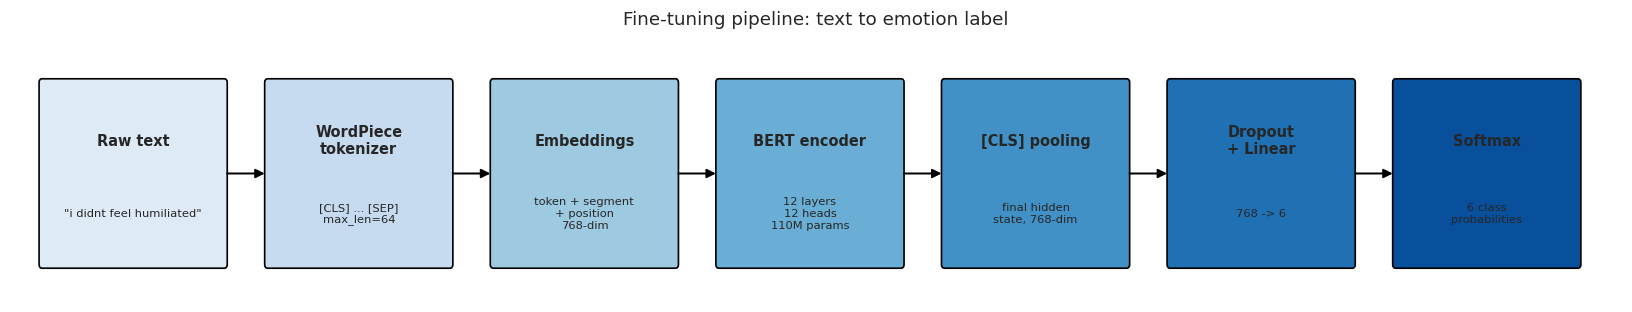

In [15]:
def plot_architecture_diagram(cfg: Config, num_labels: int) -> None:
    """Draw the end-to-end pipeline as a labelled block diagram."""
    stages = [
        ("Raw text", '"i didnt feel humiliated"'),
        ("WordPiece\ntokenizer", f"[CLS] ... [SEP]\nmax_len={cfg.max_length}"),
        ("Embeddings", "token + segment\n+ position\n768-dim"),
        ("BERT encoder", "12 layers\n12 heads\n110M params"),
        ("[CLS] pooling", "final hidden\nstate, 768-dim"),
        ("Dropout\n+ Linear", f"768 -> {num_labels}"),
        ("Softmax", f"{num_labels} class\nprobabilities"),
    ]

    fig, ax = plt.subplots(figsize=(15, 3.0))
    box_w, box_h, gap = 1.75, 1.5, 0.42
    colours = sns.color_palette("Blues", len(stages))

    for i, (title, detail) in enumerate(stages):
        x = i * (box_w + gap)
        ax.add_patch(patches.FancyBboxPatch(
            (x, 0), box_w, box_h,
            boxstyle="round,pad=0.03", facecolor=colours[i], edgecolor="black", lw=1.1
        ))
        ax.text(x + box_w / 2, box_h * 0.68, title, ha="center", va="center",
                fontsize=9.5, weight="bold")
        ax.text(x + box_w / 2, box_h * 0.28, detail, ha="center", va="center", fontsize=7.5)

        if i < len(stages) - 1:      # connecting arrow
            ax.annotate("", xy=(x + box_w + gap, box_h / 2), xytext=(x + box_w, box_h / 2),
                        arrowprops=dict(arrowstyle="-|>", lw=1.3, color="black"))

    ax.set_xlim(-0.3, len(stages) * (box_w + gap))
    ax.set_ylim(-0.3, box_h + 0.3)
    ax.axis("off")
    ax.set_title("Fine-tuning pipeline: text to emotion label", fontsize=12, pad=14)
    plt.tight_layout()
    plt.show()


plot_architecture_diagram(CFG, NUM_LABELS)

In [16]:
def build_model(cfg: Config, num_labels: int, device):
    """Instantiate a fresh classification model.

    A NEW model must be built for every experiment — reusing one would carry weights
    over between hyperparameter configurations and invalidate the comparison.
    The classification head is randomly initialised; the encoder is pretrained.
    """
    model = AutoModelForSequenceClassification.from_pretrained(
        cfg.model_name, num_labels=num_labels
    )
    return model.to(device)


# Inspect the parameter budget once, to document model size in the report.
_probe = build_model(CFG, NUM_LABELS, "cpu")
total_params = sum(p.numel() for p in _probe.parameters())
head_params = sum(p.numel() for n, p in _probe.named_parameters() if "classifier" in n)
print(f"Total parameters:          {total_params:,}")
print(f"Classification head:       {head_params:,}  (randomly initialised)")
print(f"Pretrained encoder:        {total_params - head_params:,}")
del _probe

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters:          109,486,854
Classification head:       4,614  (randomly initialised)
Pretrained encoder:        109,482,240


---
## 8. Training loop

A manual PyTorch loop is written rather than using `Trainer`, as the brief requires an
explicit optimizer and loss function.

**Loss — `CrossEntropyLoss`.** The standard choice for mutually-exclusive multi-class
targets. It operates on raw logits (applying log-softmax internally), so no softmax is
applied in the model. An optional inverse-frequency **class weighting** is available via
`Config.use_class_weights`, using the same formula as the `class_weight="balanced"` setting
already applied to the baselines in Section 6 — so no model receives imbalance handling the
others do not. Whether weighting actually helps is treated as an experiment, not an
assumption, and is tested in Section 10.1.

**Optimizer — `AdamW`.** Adam with *decoupled* weight decay. Plain Adam's L2 penalty
interacts badly with adaptive learning rates; AdamW is what BERT was designed to be
fine-tuned with. Weight decay is excluded from bias and LayerNorm parameters, following the
original BERT implementation — regularising them harms rather than helps.

**Schedule — linear warmup then linear decay.** Fine-tuning starts from a carefully
pretrained state, so a large first step can destroy it ("catastrophic forgetting"). Warmup
raises the learning rate gradually over the first 10% of steps; decay then anneals it to
zero for a stable finish.

**Gradient clipping at norm 1.0.** Cheap insurance against a single anomalous batch
producing a huge gradient.

**Early stopping on validation macro-F1, with best-checkpoint retention.** BERT overfits
small datasets within a few epochs. Two mechanisms handle this: the checkpoint with the
highest validation macro-F1 is retained rather than the final one, and training halts once
that metric has failed to improve for `patience` consecutive epochs. The two are
complementary — retention protects the result, early stopping saves the compute.

`epochs` is set to 5 rather than the conventional 3 because the learning curves showed both
validation metrics still rising at epoch 3. Note that the LR schedule is derived from total
training steps, so changing `epochs` rescales the decay: epoch *n* of a 5-epoch run is not
the same model as epoch *n* of a 3-epoch run. Compare best checkpoints across runs, never
individual epochs.

In [17]:
def compute_class_weights(labels: np.ndarray, num_labels: int, device) -> torch.Tensor:
    """Inverse-frequency class weights.

    Uses the same formula as sklearn's class_weight="balanced"
    (n_samples / (n_classes * class_count)), so the fine-tuned model and the
    logistic-regression baselines are regularised against imbalance identically.
    """
    counts = np.bincount(labels, minlength=num_labels)
    weights = len(labels) / (num_labels * counts)
    return torch.tensor(weights, dtype=torch.float, device=device)


def create_criterion(cfg: Config, train_split, num_labels: int, device) -> nn.Module:
    """Build the loss, optionally weighting classes by inverse frequency.

    Weighting raises the loss contribution of rare classes, pushing the model to
    trade precision on common classes for recall on rare ones. Whether that helps
    macro-F1 is an empirical question, tested by the ablation in Section 10.

    NOTE: loss values are not comparable between weighted and unweighted runs,
    since the two use different scales. Compare them on macro-F1 instead.
    """
    if not cfg.use_class_weights:
        return nn.CrossEntropyLoss()

    labels = np.array(train_split["labels"])
    return nn.CrossEntropyLoss(weight=compute_class_weights(labels, num_labels, device))


def create_optimizer_and_scheduler(model, cfg: Config, num_training_steps: int):
    """Build AdamW with selective weight decay, plus a warmup-then-decay schedule."""
    no_decay = ["bias", "LayerNorm.weight"]
    grouped_params = [
        {
            "params": [p for n, p in model.named_parameters()
                       if not any(nd in n for nd in no_decay)],
            "weight_decay": cfg.weight_decay,
        },
        {
            "params": [p for n, p in model.named_parameters()
                       if any(nd in n for nd in no_decay)],
            "weight_decay": 0.0,
        },
    ]

    optimizer = torch.optim.AdamW(grouped_params, lr=cfg.learning_rate)
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(cfg.warmup_ratio * num_training_steps),
        num_training_steps=num_training_steps,
    )
    return optimizer, scheduler

In [18]:
def train_one_epoch(model, dataloader, optimizer, scheduler, criterion, device, cfg) -> float:
    """Run one pass over the training data. Returns mean training loss."""
    model.train()
    total_loss = 0.0

    for batch in dataloader:
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = batch.pop("labels")

        optimizer.zero_grad()                       # gradients accumulate by default
        logits = model(**batch).logits
        loss = criterion(logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.max_grad_norm)
        optimizer.step()
        scheduler.step()                            # per-step, not per-epoch

        total_loss += loss.item()

    return total_loss / len(dataloader)


@torch.no_grad()
def evaluate(model, dataloader, criterion, device):
    """Evaluate on a dataloader. Returns (loss, metrics, predictions, labels, probabilities).

    Used unchanged for both validation and test, so the two are computed identically.
    """
    model.eval()
    total_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []

    for batch in dataloader:
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = batch.pop("labels")

        logits = model(**batch).logits
        total_loss += criterion(logits, labels).item()

        all_probs.append(torch.softmax(logits, dim=-1).cpu().numpy())
        all_preds.append(logits.argmax(dim=-1).cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_labels)

    return (total_loss / len(dataloader), compute_metrics(y_true, y_pred),
            y_pred, y_true, np.vstack(all_probs))

In [19]:
def run_experiment(cfg: Config, train_split, val_split, tokenizer, device,
                   num_labels: int, epochs: int = None, verbose: bool = True) -> dict:
    """Train one model end-to-end and return the best checkpoint plus its history.

    This is the single reusable unit of work: the hyperparameter search (Section 9)
    and the final training run (Section 10) both call it, differing only in config.
    """
    epochs = epochs or cfg.epochs
    set_seed(cfg.seed)                     # re-seed so each run starts identically

    train_loader = build_dataloader(train_split, tokenizer, cfg.batch_size, shuffle=True)
    val_loader = build_dataloader(val_split, tokenizer, cfg.batch_size, shuffle=False)

    model = build_model(cfg, num_labels, device)
    criterion = create_criterion(cfg, train_split, num_labels, device)
    optimizer, scheduler = create_optimizer_and_scheduler(
        model, cfg, num_training_steps=len(train_loader) * epochs
    )

    history = {"train_loss": [], "val_loss": [], "val_accuracy": [], "val_macro_f1": []}
    best_f1, best_state, best_epoch = -1.0, None, -1
    epochs_without_improvement = 0
    start = time.time()

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(
            model, train_loader, optimizer, scheduler, criterion, device, cfg
        )
        val_loss, val_metrics, _, _, _ = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_metrics["accuracy"])
        history["val_macro_f1"].append(val_metrics["macro_f1"])

        # Keep the best checkpoint by validation macro-F1, not the final one.
        if val_metrics["macro_f1"] > best_f1:
            best_f1 = val_metrics["macro_f1"]
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if verbose:
            print(f"  epoch {epoch}/{epochs} | train loss {train_loss:.4f} | "
                  f"val loss {val_loss:.4f} | val macro-F1 {val_metrics['macro_f1']:.4f}")

        # Early stopping: halt once validation macro-F1 has stalled, since further
        # epochs only overfit. The best checkpoint is already saved, so nothing is lost.
        if epochs_without_improvement >= cfg.patience:
            if verbose:
                print(f"  early stop: no improvement for {cfg.patience} epochs")
            break

    model.load_state_dict(best_state)      # restore best before returning
    return {
        "model": model,
        "history": history,
        "best_val_macro_f1": best_f1,
        "best_epoch": best_epoch,
        "runtime_seconds": time.time() - start,
    }

---
## 9. Hyperparameter tuning

Learning rate is the hyperparameter fine-tuning is most sensitive to, so the search covers
the range recommended in the original BERT paper (`2e-5`, `3e-5`, `5e-5`) crossed with two
batch sizes.

Two efficiency measures keep this affordable, both of which are trade-offs worth naming:

- Each configuration trains on a **stratified subsample** of the training set
  (`tune_subsample`). Stratified sampling preserves the class balance from Section 3.1, so
  the rare classes are still represented. The assumption is that the *ranking* of
  configurations is stable under subsampling even though absolute scores are lower.
- Search runs use fewer epochs (`tune_epochs`); the winning configuration is then retrained
  in full in Section 10.

**Selection is on validation macro-F1. The test set is not touched in this section.**

In [20]:
def stratified_subsample(dataset, fraction: float, labels: np.ndarray, seed: int):
    """Take a class-proportional subsample, preserving the original class balance."""
    if fraction >= 1.0:
        return dataset

    rng = np.random.default_rng(seed)
    keep = []
    for cls in np.unique(labels):
        idx = np.where(labels == cls)[0]
        n = max(1, int(round(len(idx) * fraction)))
        keep.extend(rng.choice(idx, size=n, replace=False).tolist())

    return dataset.select(sorted(keep))


def hyperparameter_search(base_cfg: Config, train_split, val_split, train_labels,
                          tokenizer, device, num_labels: int,
                          learning_rates, batch_sizes) -> pd.DataFrame:
    """Grid-search over learning rate and batch size, scored on validation macro-F1."""
    tuning_split = stratified_subsample(
        train_split, base_cfg.tune_subsample, train_labels, base_cfg.seed
    )
    print(f"Tuning on {len(tuning_split):,} of {len(train_split):,} training examples "
          f"for {base_cfg.tune_epochs} epochs each.\n")

    records = []
    for lr in learning_rates:
        for bs in batch_sizes:
            cfg = replace(base_cfg, learning_rate=lr, batch_size=bs)
            print(f"lr={lr:g}, batch_size={bs}")

            result = run_experiment(cfg, tuning_split, val_split, tokenizer,
                                    device, num_labels, epochs=cfg.tune_epochs)

            records.append({
                "learning_rate": lr,
                "batch_size": bs,
                "val_macro_f1": result["best_val_macro_f1"],
                "best_epoch": result["best_epoch"],
                "minutes": result["runtime_seconds"] / 60,
            })

            del result["model"]              # free GPU memory before the next config
            torch.cuda.empty_cache()
            print()

    return pd.DataFrame(records).sort_values("val_macro_f1", ascending=False)


search_results = hyperparameter_search(
    CFG, encoded_datasets["train"], encoded_datasets["validation"],
    train_df["label"].values, tokenizer, DEVICE, NUM_LABELS,
    learning_rates=[2e-5, 3e-5, 5e-5],
    batch_sizes=[16, 32],
)

# Round only the metric columns for display - rounding `learning_rate` itself to 4
# decimal places would zero out values like 2e-05, since 0.00002 rounds to 0.0000.
display_results = search_results.copy()
display_results["val_macro_f1"] = display_results["val_macro_f1"].round(4)
display_results["minutes"] = display_results["minutes"].round(2)

print("Search results (ranked by validation macro-F1):")
display_results

Tuning on 8,000 of 16,000 training examples for 2 epochs each.

lr=2e-05, batch_size=16


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  epoch 1/2 | train loss 0.8426 | val loss 0.2989 | val macro-F1 0.8731
  epoch 2/2 | train loss 0.2023 | val loss 0.2255 | val macro-F1 0.8908

lr=2e-05, batch_size=32


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

  epoch 1/2 | train loss 0.6641 | val loss 0.2588 | val macro-F1 0.8964
  epoch 2/2 | train loss 0.1708 | val loss 0.1915 | val macro-F1 0.8972

lr=5e-05, batch_size=32


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  epoch 1/2 | train loss 0.7560 | val loss 0.2295 | val macro-F1 0.8976
  epoch 2/2 | train loss 0.1672 | val loss 0.1830 | val macro-F1 0.9067

Search results (ranked by validation macro-F1):


,learning_rate,batch_size,val_macro_f1,best_epoch,minutes
5,0.00005,32,0.9067,2,2.73
2,0.00003,16,0.9037,2,2.92
4,0.00005,16,0.8972,2,2.92
3,0.00003,32,0.8933,2,2.73
0,0.00002,16,0.8908,2,2.94
1,0.00002,32,0.8730,2,2.74


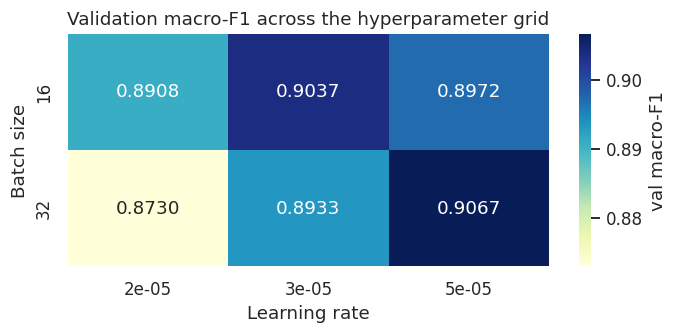

Selected: lr=5e-05, batch_size=32 (validation macro-F1 0.9067)


In [21]:
def plot_search_results(results: pd.DataFrame) -> None:
    """Heatmap of validation macro-F1 across the hyperparameter grid."""
    grid = results.pivot(index="batch_size", columns="learning_rate", values="val_macro_f1")

    plt.figure(figsize=(6.5, 3.2))
    sns.heatmap(grid, annot=True, fmt=".4f", cmap="YlGnBu", cbar_kws={"label": "val macro-F1"})
    plt.title("Validation macro-F1 across the hyperparameter grid")
    plt.xlabel("Learning rate")
    plt.ylabel("Batch size")
    plt.tight_layout()
    plt.show()


plot_search_results(search_results)

# Adopt the winning configuration for the final run.
best_row = search_results.iloc[0]
BEST_CFG = replace(
    CFG,
    learning_rate=float(best_row["learning_rate"]),
    batch_size=int(best_row["batch_size"]),
)
print(f"Selected: lr={BEST_CFG.learning_rate:g}, batch_size={BEST_CFG.batch_size} "
      f"(validation macro-F1 {best_row['val_macro_f1']:.4f})")

---
## 10. Final training and learning curves

The winning configuration is now retrained on the **full** training set for the full number
of epochs. Learning curves are plotted to check the run behaved: training loss should fall
steadily, and the point where validation loss turns upward while training loss keeps
falling marks the onset of overfitting — which is exactly why the best-checkpoint logic in
`run_experiment` matters.

Two variants are trained: standard cross-entropy and inverse-frequency **class-weighted**
cross-entropy. The winner is chosen on validation macro-F1 and is the only model that goes
on to the test set, so the imbalance strategy is selected on evidence without spending test
data to do it.

Setting `CFG.n_final_seeds` to 3 repeats each variant with different seeds and reports mean
and standard deviation. A single seed is used by default for runtime, but multiple seeds are
the more defensible way to report a small margin — and the weighted/unweighted margin is
often small enough that one seed cannot separate them.

In [22]:
def train_final_models(cfg: Config, train_split, val_split, tokenizer, device, num_labels):
    """Train the selected configuration under BOTH loss variants, across seeds.

    Running weighted and unweighted cross-entropy as a controlled ablation means the
    imbalance strategy is chosen on evidence rather than assumed, and it matches the
    class weighting already applied to the logistic-regression baselines.
    """
    runs = []
    for use_weights in (False, True):
        variant = "weighted" if use_weights else "unweighted"
        for i in range(cfg.n_final_seeds):
            run_cfg = replace(cfg, use_class_weights=use_weights, seed=cfg.seed + i)
            print(f"[{variant} loss] seed {run_cfg.seed}")

            result = run_experiment(run_cfg, train_split, val_split,
                                    tokenizer, device, num_labels)
            result["variant"] = variant
            result["seed"] = run_cfg.seed
            runs.append(result)
            print()
    return runs


final_runs = train_final_models(
    BEST_CFG, encoded_datasets["train"], encoded_datasets["validation"],
    tokenizer, DEVICE, NUM_LABELS
)

# Summarise both variants on VALIDATION; the test set is still untouched.
variant_summary = (
    pd.DataFrame([{"variant": r["variant"], "seed": r["seed"],
                   "val_macro_f1": r["best_val_macro_f1"], "best_epoch": r["best_epoch"]}
                  for r in final_runs])
    .groupby("variant")["val_macro_f1"]
    .agg(["mean", "std", "max"])
    .round(4)
)
print("Validation macro-F1 by loss variant:")
print(variant_summary)

# Selection rule: best validation macro-F1 wins and goes forward to test.
best_run = max(final_runs, key=lambda r: r["best_val_macro_f1"])
final_model = best_run["model"]
print(f"\nSelected: {best_run['variant']} loss, seed {best_run['seed']}, "
      f"epoch {best_run['best_epoch']} (val macro-F1 {best_run['best_val_macro_f1']:.4f})")

[unweighted loss] seed 42


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  epoch 1/5 | train loss 0.6589 | val loss 0.2109 | val macro-F1 0.8986
  epoch 2/5 | train loss 0.1462 | val loss 0.1250 | val macro-F1 0.9088
  epoch 3/5 | train loss 0.0978 | val loss 0.1327 | val macro-F1 0.9159
  epoch 4/5 | train loss 0.0698 | val loss 0.1874 | val macro-F1 0.9128
  epoch 5/5 | train loss 0.0440 | val loss 0.2045 | val macro-F1 0.9140
  early stop: no improvement for 2 epochs

[weighted loss] seed 42


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  epoch 1/5 | train loss 0.8020 | val loss 0.2267 | val macro-F1 0.9048
  epoch 2/5 | train loss 0.1771 | val loss 0.1623 | val macro-F1 0.9043
  epoch 3/5 | train loss 0.1271 | val loss 0.1867 | val macro-F1 0.9115
  epoch 4/5 | train loss 0.1039 | val loss 0.2640 | val macro-F1 0.9123
  epoch 5/5 | train loss 0.0640 | val loss 0.2820 | val macro-F1 0.9126

Validation macro-F1 by loss variant:
              mean  std     max
variant                        
unweighted  0.9159  NaN  0.9159
weighted    0.9126  NaN  0.9126

Selected: unweighted loss, seed 42, epoch 3 (val macro-F1 0.9159)


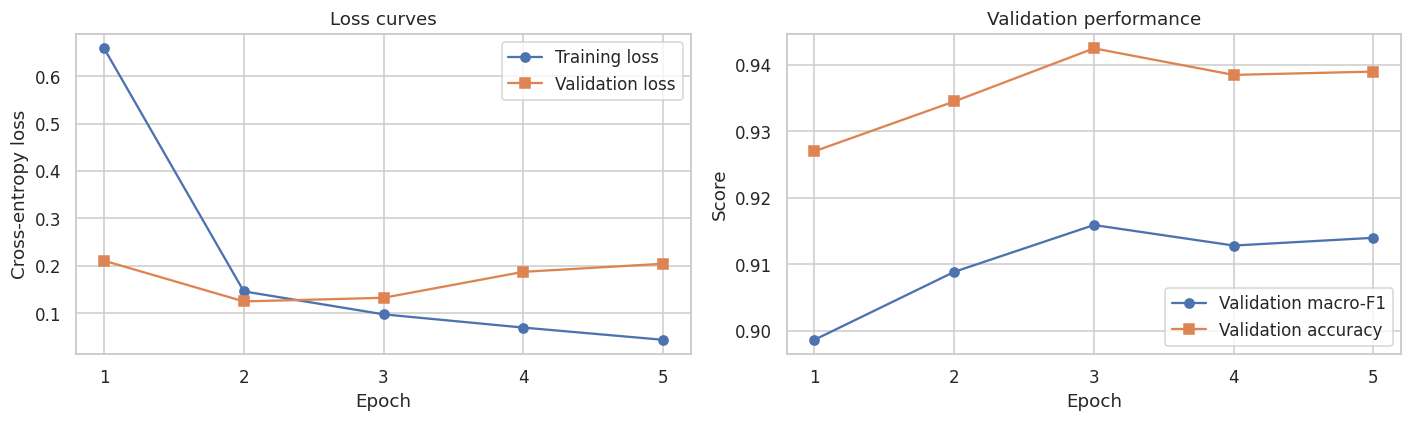

In [23]:
def plot_learning_curves(history: dict) -> None:
    """Plot loss and validation metric curves side by side."""
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(epochs, history["train_loss"], "o-", label="Training loss")
    axes[0].plot(epochs, history["val_loss"], "s-", label="Validation loss")
    axes[0].set_title("Loss curves")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Cross-entropy loss")
    axes[0].set_xticks(list(epochs))
    axes[0].legend()

    axes[1].plot(epochs, history["val_macro_f1"], "o-", label="Validation macro-F1")
    axes[1].plot(epochs, history["val_accuracy"], "s-", label="Validation accuracy")
    axes[1].set_title("Validation performance")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Score")
    axes[1].set_xticks(list(epochs))
    axes[1].legend()

    plt.tight_layout()
    plt.show()


plot_learning_curves(best_run["history"])

### 10.1 Does class weighting help?

The bar chart below is the substantive answer to "how was imbalance handled". Weighting
the loss by inverse class frequency should, if it works, raise recall on the rarest classes
at some cost to the common ones. Comparing **per-class** F1 rather than the aggregate is
what reveals whether the trade actually paid off, and where.

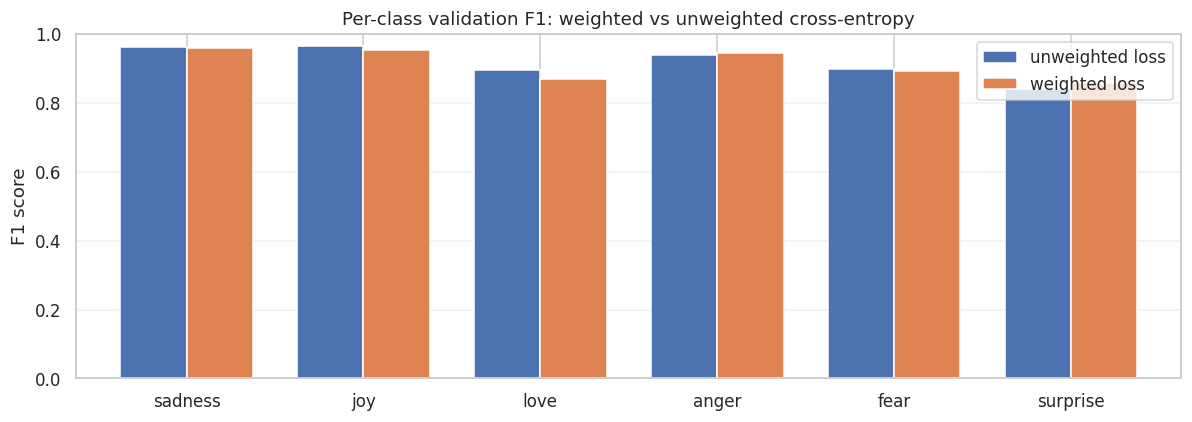

Sorted by support (rarest class first) - check whether `delta` is positive there:
          unweighted loss  weighted loss  support   delta
surprise           0.8387         0.8571       81  0.0184
love               0.8935         0.8693      178 -0.0242
fear               0.8972         0.8926      212 -0.0046
anger              0.9392         0.9433      275  0.0042
sadness            0.9618         0.9593      550 -0.0026
joy                0.9649         0.9538      704 -0.0111


In [24]:
def compare_loss_variants(runs, val_split, cfg, tokenizer, device, label_names) -> pd.DataFrame:
    """Compare per-class validation F1 between the weighted and unweighted models."""
    val_loader = build_dataloader(val_split, tokenizer, cfg.batch_size, shuffle=False)
    plain_loss = nn.CrossEntropyLoss()      # evaluation only; we need predictions, not loss

    rows, support = {}, None
    for variant in ("unweighted", "weighted"):
        best = max((r for r in runs if r["variant"] == variant),
                   key=lambda r: r["best_val_macro_f1"])
        _, _, y_pred_v, y_true_v, _ = evaluate(best["model"], val_loader, plain_loss, device)
        _, _, f1, sup = precision_recall_fscore_support(
            y_true_v, y_pred_v, average=None, zero_division=0
        )
        rows[f"{variant} loss"] = f1
        support = sup

    table = pd.DataFrame(rows, index=label_names)
    table["support"] = support
    table["delta"] = table["weighted loss"] - table["unweighted loss"]

    ax = table[["unweighted loss", "weighted loss"]].plot(kind="bar", figsize=(11, 4), width=0.75)
    ax.set_title("Per-class validation F1: weighted vs unweighted cross-entropy")
    ax.set_ylabel("F1 score")
    ax.set_ylim(0, 1.0)
    ax.tick_params(axis="x", rotation=0)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    return table.sort_values("support").round(4)


weighting_ablation = compare_loss_variants(
    final_runs, encoded_datasets["validation"], BEST_CFG, tokenizer, DEVICE, LABEL_NAMES
)
print("Sorted by support (rarest class first) - check whether `delta` is positive there:")
print(weighting_ablation)

---
## 11. Test-set evaluation

The test set is now used for the first and only time. Everything up to this point —
`max_length`, the hyperparameter grid, the epoch the checkpoint came from — was decided on
training and validation data alone.

In [25]:
test_loader = build_dataloader(
    encoded_datasets["test"], tokenizer, BEST_CFG.batch_size, shuffle=False
)

test_loss, bert_metrics, y_pred, y_true, y_probs = evaluate(
    final_model, test_loader, nn.CrossEntropyLoss(), DEVICE
)
results_registry["Fine-tuned BERT"] = bert_metrics

print(format_metrics("Fine-tuned BERT", bert_metrics))
print(f"\nTest loss: {test_loss:.4f}")

Fine-tuned BERT              acc 0.9370 | macro-F1 0.8919 | weighted-F1 0.9353

Test loss: 0.1531


In [26]:
# Per-class breakdown: this is where the imbalance from Section 3.1 becomes visible.
print(classification_report(y_true, y_pred, target_names=LABEL_NAMES, digits=4))

              precision    recall  f1-score   support

     sadness     0.9597    0.9828    0.9711       581
         joy     0.9340    0.9770    0.9550       695
        love     0.9154    0.7484    0.8235       159
       anger     0.9727    0.9055    0.9379       275
        fear     0.8797    0.9464    0.9118       224
    surprise     0.8627    0.6667    0.7521        66

    accuracy                         0.9370      2000
   macro avg     0.9207    0.8711    0.8919      2000
weighted avg     0.9368    0.9370    0.9353      2000



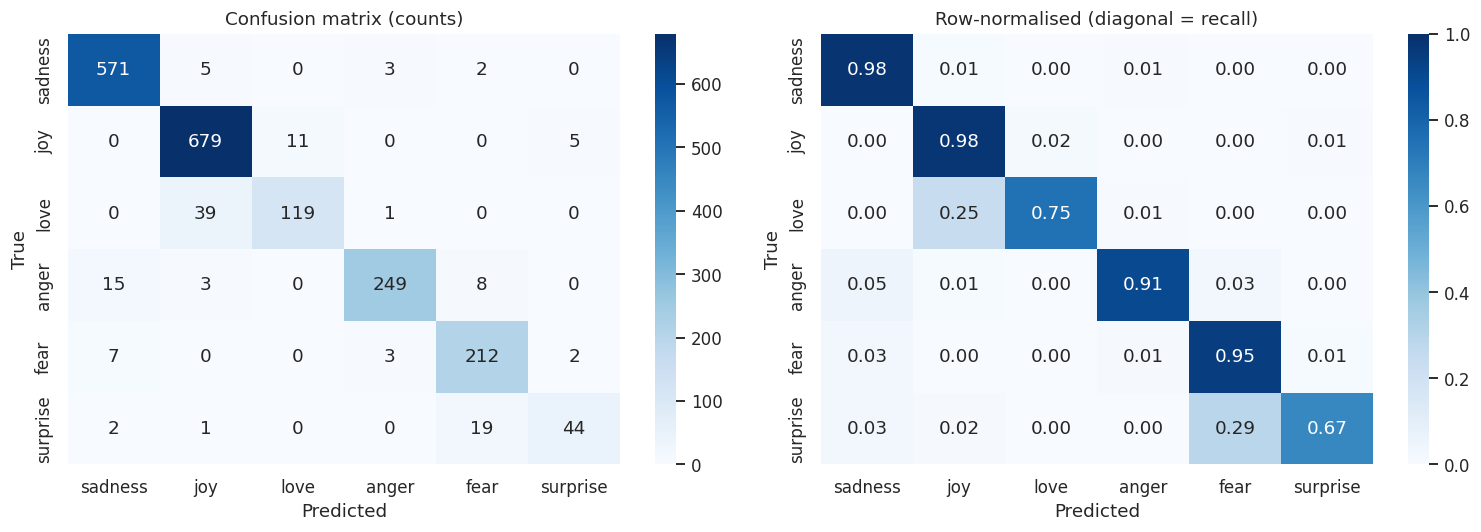

Largest confusions:
   surprise misread as fear      28.8% of the time
       love misread as joy       24.5% of the time
      anger misread as sadness   5.5% of the time
       fear misread as sadness   3.1% of the time


In [27]:
def plot_confusion_matrix(y_true, y_pred, label_names) -> None:
    """Plot raw and row-normalised confusion matrices.

    Row-normalising (dividing by true-class totals) gives per-class RECALL on the
    diagonal, which makes rare classes comparable to common ones, raw counts alone
    would make every rare class look uniformly dark regardless of performance.
    """
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
                xticklabels=label_names, yticklabels=label_names)
    axes[0].set_title("Confusion matrix (counts)")

    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", ax=axes[1],
                xticklabels=label_names, yticklabels=label_names, vmin=0, vmax=1)
    axes[1].set_title("Row-normalised (diagonal = recall)")

    for ax in axes:
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")

    plt.tight_layout()
    plt.show()

    # Surface the largest off-diagonal confusions for the discussion in Section 13.
    np.fill_diagonal(cm_norm, 0)
    print("Largest confusions:")
    for _ in range(4):
        i, j = np.unravel_index(cm_norm.argmax(), cm_norm.shape)
        print(f"  {label_names[i]:>9} misread as {label_names[j]:<9} "
              f"{cm_norm[i, j]:.1%} of the time")
        cm_norm[i, j] = 0


plot_confusion_matrix(y_true, y_pred, LABEL_NAMES)

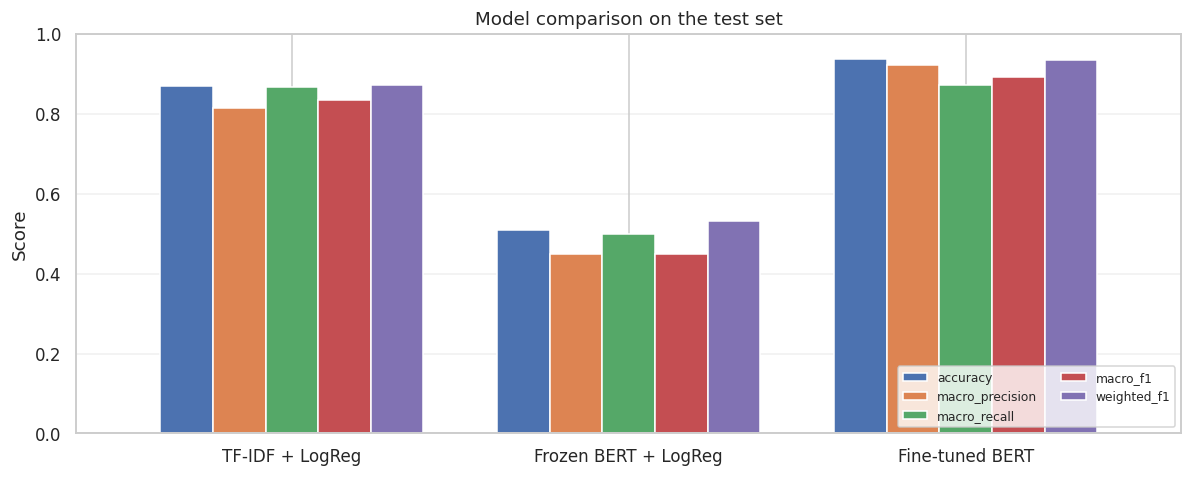

                      accuracy  macro_precision  macro_recall  macro_f1  \
TF-IDF + LogReg          0.869           0.8135        0.8674    0.8345   
Frozen BERT + LogReg     0.509           0.4483        0.4993    0.4498   
Fine-tuned BERT          0.937           0.9207        0.8711    0.8919   

                      weighted_f1  
TF-IDF + LogReg            0.8713  
Frozen BERT + LogReg       0.5316  
Fine-tuned BERT            0.9353  

Fine-tuning improves macro-F1 by +0.0574 over the TF-IDF baseline.


In [28]:
def plot_model_comparison(registry: dict) -> pd.DataFrame:
    """Grouped bar chart plus table comparing every model on the same test set."""
    comparison = pd.DataFrame(registry).T[
        ["accuracy", "macro_precision", "macro_recall", "macro_f1", "weighted_f1"]
    ]

    ax = comparison.plot(kind="bar", figsize=(11, 4.5), width=0.78)
    ax.set_title("Model comparison on the test set")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.0)
    ax.tick_params(axis="x", rotation=0)
    ax.legend(loc="lower right", ncol=2, fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    return comparison.round(4)


comparison_table = plot_model_comparison(results_registry)
print(comparison_table)

gain = (results_registry["Fine-tuned BERT"]["macro_f1"]
        - results_registry["TF-IDF + LogReg"]["macro_f1"])
print(f"\nFine-tuning improves macro-F1 by {gain:+.4f} over the TF-IDF baseline.")

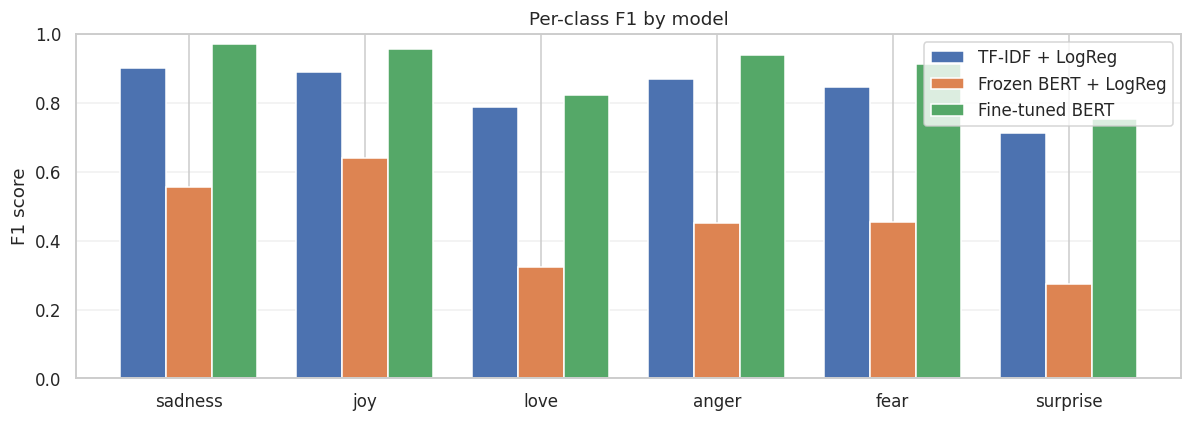

          TF-IDF + LogReg  Frozen BERT + LogReg  Fine-tuned BERT
sadness            0.9004                0.5557           0.9711
joy                0.8899                0.6405           0.9550
love               0.7889                0.3226           0.8235
anger              0.8694                0.4513           0.9379
fear               0.8460                0.4542           0.9118
surprise           0.7125                0.2747           0.7521


In [29]:
def plot_per_class_comparison(y_true, predictions: dict, label_names) -> None:
    """Per-class F1 for each model — shows WHERE the improvement comes from."""
    rows = {}
    for name, preds in predictions.items():
        _, _, f1, _ = precision_recall_fscore_support(
            y_true, preds, average=None, zero_division=0
        )
        rows[name] = f1

    per_class = pd.DataFrame(rows, index=label_names)

    ax = per_class.plot(kind="bar", figsize=(11, 4), width=0.78)
    ax.set_title("Per-class F1 by model")
    ax.set_ylabel("F1 score")
    ax.set_ylim(0, 1.0)
    ax.tick_params(axis="x", rotation=0)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(per_class.round(4))


plot_per_class_comparison(
    y_true,
    {"TF-IDF + LogReg": tfidf_preds,
     "Frozen BERT + LogReg": frozen_preds,
     "Fine-tuned BERT": y_pred},
    LABEL_NAMES,
)

---
## 12. Error analysis

Aggregate metrics say *how much* the model fails; reading the failures says *why*. Errors
are sorted by model confidence, because confident mistakes are the informative ones, they
reveal systematic problems rather than borderline cases.

In [30]:
def inspect_errors(texts, y_true, y_pred, y_probs, label_names, n=15) -> pd.DataFrame:
    """Return the most confidently wrong predictions for manual inspection."""
    wrong = np.where(y_true != y_pred)[0]
    confidence = y_probs[wrong, y_pred[wrong]]
    ranked = wrong[np.argsort(-confidence)][:n]

    return pd.DataFrame({
        "text": [texts[i] for i in ranked],
        "true": [label_names[y_true[i]] for i in ranked],
        "predicted": [label_names[y_pred[i]] for i in ranked],
        "confidence": y_probs[ranked, y_pred[ranked]].round(3),
    })


error_rate = (y_true != y_pred).mean()
print(f"Overall error rate: {error_rate:.2%} "
      f"({(y_true != y_pred).sum()} of {len(y_true)} test examples)\n")
print("Most confident mistakes:")
inspect_errors(test_df["text"].tolist(), y_true, y_pred, y_probs, LABEL_NAMES)

Overall error rate: 6.30% (126 of 2000 test examples)

Most confident mistakes:


,text,true,predicted,confidence
0,whenever i put myself in others shoes and try to make the person happy,anger,joy,0.999
1,i feel inside cause life is like a game sometimes but then you came around me the wall...,fear,sadness,0.999
2,i feel so blessed and honored that we get to be its parents,love,joy,0.999
3,i cannot even begin to express in words the depth of sorrow that i feel having not pos...,surprise,sadness,0.999
4,i feel lonely who make me feel special when i feel useless who are always kind and swe...,sadness,joy,0.999
5,i just feel are ludicrous and wasting space or so trite they should have looked at the...,surprise,sadness,0.998
6,i feel betrayed and angry and sad at the same time dammit,anger,sadness,0.997
7,i felt a stronger wish to be free from self cherishing through my refuge practice and ...,sadness,joy,0.996
8,i cant help feeling this way,sadness,joy,0.996
9,i walked to school he felt the bounce in his step the overjoyed feelings of youth and ...,love,joy,0.994


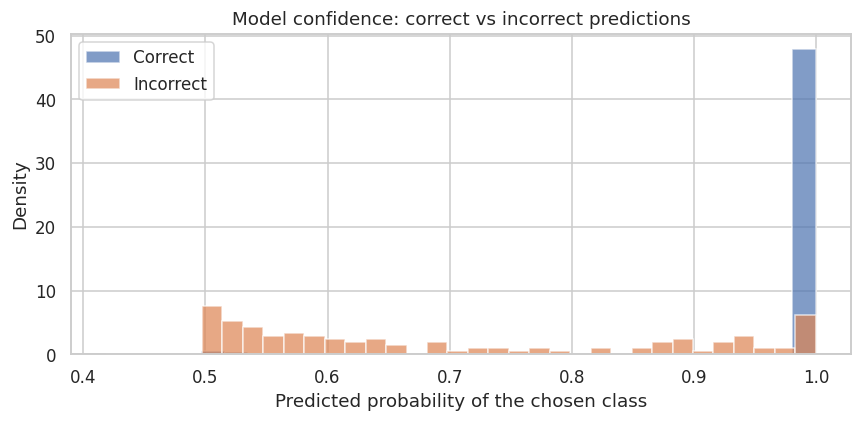

Mean confidence when correct:   0.975
Mean confidence when incorrect: 0.699


In [31]:
def confidence_analysis(y_true, y_pred, y_probs) -> None:
    """Compare the confidence distribution of correct vs incorrect predictions.

    A well-behaved model should be markedly less confident when it is wrong. If the
    two distributions overlap heavily, the model's probabilities are poorly calibrated
    and should not be used as a reliability signal downstream.
    """
    confidence = y_probs.max(axis=1)
    correct = y_true == y_pred

    plt.figure(figsize=(8, 4))
    plt.hist(confidence[correct], bins=30, alpha=0.7, label="Correct", density=True)
    plt.hist(confidence[~correct], bins=30, alpha=0.7, label="Incorrect", density=True)
    plt.xlabel("Predicted probability of the chosen class")
    plt.ylabel("Density")
    plt.title("Model confidence: correct vs incorrect predictions")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"Mean confidence when correct:   {confidence[correct].mean():.3f}")
    print(f"Mean confidence when incorrect: {confidence[~correct].mean():.3f}")


confidence_analysis(y_true, y_pred, y_probs)